In [1]:
from pathlib import Path
from typing import Literal
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [2]:
EmbeddingModelType = Literal['glove', 'word2vec']

GLOVE_TXT_PATH = Path('../models/glove.6B.300d.txt')
GLOVE_W2V_TXT_PATH = Path('../models/glove.6B.300d.word2vec.txt')
WORD_2_VEC_PATH = Path('../models/GoogleNews-vectors-negative300.bin.gz')

In [3]:
def load_embedding_model(model_type: EmbeddingModelType) -> KeyedVectors:
    if model_type == 'glove':
        if not GLOVE_W2V_TXT_PATH.exists():
            glove2word2vec(str(GLOVE_TXT_PATH), str(GLOVE_W2V_TXT_PATH))
        model = KeyedVectors.load_word2vec_format(str(GLOVE_W2V_TXT_PATH), binary=False)
    elif model_type == 'word2vec':
        model = KeyedVectors.load_word2vec_format(str(WORD_2_VEC_PATH), binary=True)
    else:
        raise ValueError("Embedding model not supported. Must be either 'glove' or 'word2vec'")
    return model

In [4]:
model = load_embedding_model(model_type='glove')

## Identify Gender Subspace

In [6]:
male_words = [line.strip() for line in open('../data/male_word_file.txt')]
male_words = [word for word in male_words if word in model]

female_words = [line.strip() for line in open('../data/female_word_file.txt')]
female_words = [word for word in female_words if word in model]

In [7]:
male_word_embeddings = np.array([model[word] for word in male_words])
female_word_embeddings = np.array([model[word] for word in female_words])
all_word_embeddings = np.vstack((male_word_embeddings, female_word_embeddings))

In [8]:
def build_definitional_pairs_matrix(model: KeyedVectors, word_concept_pairs: list[tuple[str, str]]) -> np.ndarray:
    rows = []
    for word1, word2 in word_concept_pairs:
        if word1 in model and word2 in model:
            emb1 = model[word1]
            emb2 = model[word2]
            center = (emb1 + emb2) / 2.0
            rows.append(emb1 - center)
            rows.append(emb2 - center)
        else:
            print(f"Warning: One of the words '{word1}' or '{word2}' not in vocabulary. Skipping pair.")

    if not rows:
        raise ValueError("No valid word pairs found in the model vocabulary.")

    return np.vstack(rows) # shape: (2 * number_of_pairs, embedding_dim)

In [46]:
# gender_definitional_pairs = [
#     ('female', 'male'), ('woman', 'man'), ('she', 'he'),
#     ('girl', 'boy'), ('mother', 'father'), ('daughter', 'son'),
#     ('wife', 'husband'), ('lady', 'gentleman'), ('sister', 'brother'),
# ]

gender_definitional_pairs = [
    ('woman', 'man'), ('she', 'he'), ('girl', 'boy'),
]

definitional_gender_matrix = build_definitional_pairs_matrix(model, gender_definitional_pairs)

In [47]:
gender_pca = PCA(n_components=min(10, definitional_gender_matrix.shape[0]), random_state=42)
gender_pca.fit(definitional_gender_matrix)

,n_components,6
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


In [48]:
print(f"Explained variance ratio: {gender_pca.explained_variance_ratio_}")

Explained variance ratio: [7.5726455e-01 1.2460881e-01 1.1812668e-01 8.1412377e-15 1.9324148e-15
 8.5242532e-16]


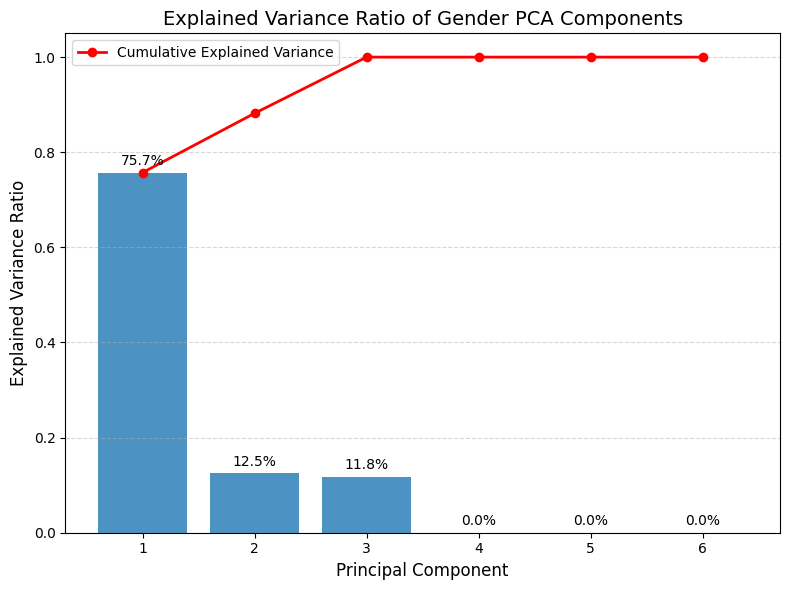

In [53]:
evr = gender_pca.explained_variance_ratio_
cumulative = np.cumsum(evr)

plt.figure(figsize=(8,6))
bars = plt.bar(range(1, len(evr) + 1), evr, alpha=0.8)
for i, b in enumerate(bars):
    height = b.get_height()
    plt.text(b.get_x() + b.get_width() / 2, height + 0.01, f"{height*100:.1f}%", ha='center', va='bottom', fontsize=10)
plt.plot(range(1, len(evr) +1), cumulative, marker='o', linewidth=2, color='red', label='Cumulative Explained Variance')

plt.title("Explained Variance Ratio of Gender PCA Components", fontsize=14)
plt.xlabel("Principal Component", fontsize=12)
plt.ylabel("Explained Variance Ratio", fontsize=12)
plt.xticks(range(1, len(evr) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

bachelor
airmen
ma
wenches


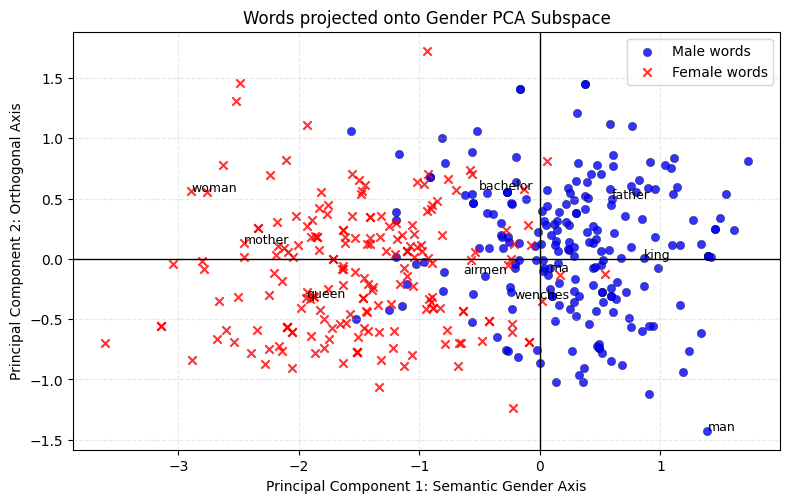

In [85]:
X_gender = gender_pca.transform(all_word_embeddings)
X_gender_2d = X_gender[:, :2]

n_male = len(male_words)
X_male = X_gender_2d[:n_male]
X_female = X_gender_2d[n_male:]

x_male, y_male = X_male[:, 0], X_male[:, 1]
x_female, y_female = X_female[:, 0], X_female[:, 1]

# k = 3
# all_x = np.concatenate([x_male, x_female])
# all_words = male_words + female_words
#
# indices_sorted = np.argsort(np.abs(all_x))
# border_indices = indices_sorted[:k]

male_wrong_idx = np.where(x_male < 0)[0]
female_wrong_idx = np.where(x_female > 0)[0]

k = 2
male_wrong_idx = male_wrong_idx[:k]
female_wrong_idx = female_wrong_idx[:k]

plt.figure(figsize=(8, 6))
plt.scatter(x_male, y_male, c='blue', marker="o", alpha=0.8, edgecolors="k", linewidths=0.3,label="Male words")
plt.scatter(x_female, y_female, c='red', marker="x", alpha=0.8, label="Female words")

example_words = ["man", "woman", "king", "queen", "father", "mother"]
for w in example_words:
    if w in model:
        z = gender_pca.transform(model[w].reshape(1, -1))[0]
        plt.text(z[0], z[1], w, fontsize=9)

# for idx in border_indices:
#     w = all_words[idx]
#     x = all_x[idx]
#     y = X_gender_2d[idx, 1]
#     plt.text(x, y, w, fontsize=9, ha='center', va='bottom')

for i in male_wrong_idx:
    print(male_words[i])
    plt.text(x_male[i], y_male[i], male_words[i],
             fontsize=9, ha='center', va='bottom')

for i in female_wrong_idx:
    print(female_words[i])
    plt.text(x_female[i], y_female[i], female_words[i],
             fontsize=9, ha='center', va='bottom')

plt.axvline(0, color='black', linewidth=1)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel("Principal Component 1: Semantic Gender Axis")
plt.ylabel("Principal Component 2: Orthogonal Axis")
plt.title("Words projected onto Gender PCA Subspace")
plt.legend()
plt.grid(alpha=0.3, linestyle="--")
plt.gca().set_aspect("equal", "box")
plt.tight_layout()
plt.show()

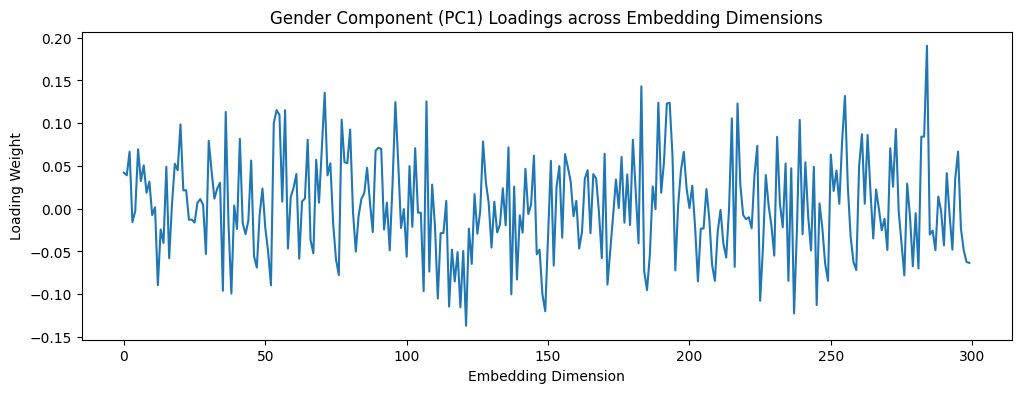

In [57]:
plt.figure(figsize=(12, 4))
plt.plot(gender_pca.components_[0])
plt.title("Gender Component (PC1) Loadings across Embedding Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Loading Weight")
plt.show()

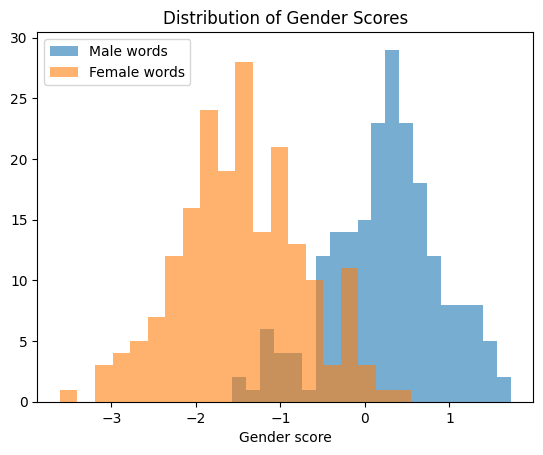

In [60]:
gender_axis = gender_pca.components_[0]
gender_axis = gender_axis / np.linalg.norm(gender_axis)

def gender_score(word):
    return np.dot(model[word], gender_axis)

male_scores = [gender_score(w) for w in male_words]
female_scores = [gender_score(w) for w in female_words]

plt.hist(male_scores, bins=20, alpha=0.6, label='Male words')
plt.hist(female_scores, bins=20, alpha=0.6, label='Female words')
plt.legend()
plt.xlabel("Gender score")
plt.title("Distribution of Gender Scores")
plt.show()

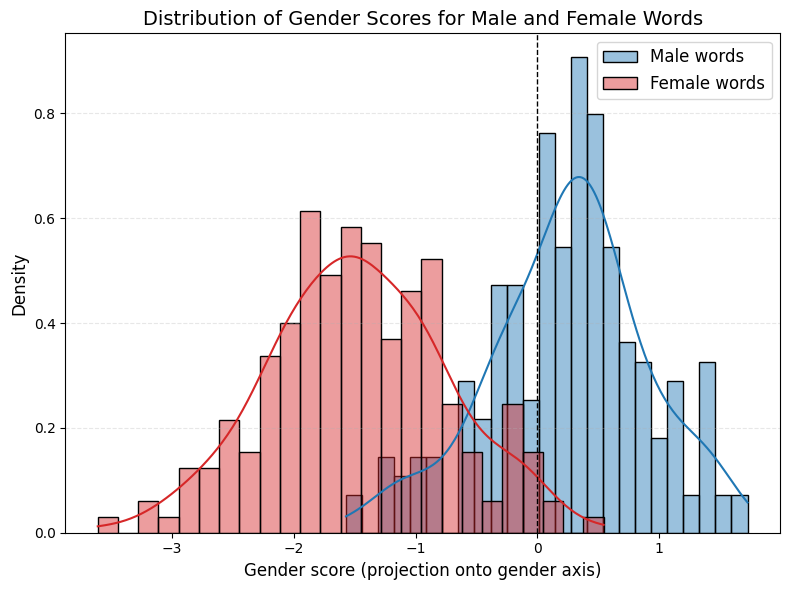

In [59]:
import seaborn as sns
plt.figure(figsize=(8, 6))

# Histogram + KDE for male words
sns.histplot(male_scores, bins=25, kde=True, stat="density",
             color="#1f77b4", alpha=0.45, label="Male words")

# Histogram + KDE for female words
sns.histplot(female_scores, bins=25, kde=True, stat="density",
             color="#d62728", alpha=0.45, label="Female words")

plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.legend(fontsize=12)
plt.xlabel("Gender score (projection onto gender axis)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Distribution of Gender Scores for Male and Female Words", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
def cosine_sim(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

def remove_pc1(vec):
    return vec - np.dot(vec, gender_axis) * gender_axis

man_deb = remove_pc1(model["man"])
woman_deb = remove_pc1(model["woman"])

before = model.similarity("man", "woman")
after = cosine_sim(man_deb, woman_deb)

print("Similarity before debiasing:", before)
print("Similarity after debiasing:", after)

Similarity before debiasing: 0.69986635
Similarity after debiasing: 0.87087655


AUC using PC1 gender score: 0.9573283858998145


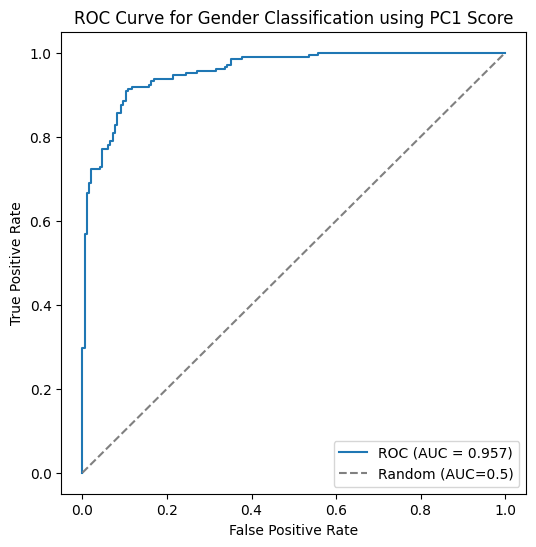

In [86]:
from sklearn.metrics import roc_curve, roc_auc_score

scores = np.array(male_scores + female_scores)
labels = np.array([1] * len(male_scores) + [0] * len(female_scores))

auc = roc_auc_score(labels, scores)
print("AUC using PC1 gender score:", auc)

fpr, tpr, thresholds = roc_curve(labels, scores)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random (AUC=0.5)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Gender Classification using PC1 Score")
plt.legend()
plt.show()

AUC with full 300D embeddings: 0.9677158999192897


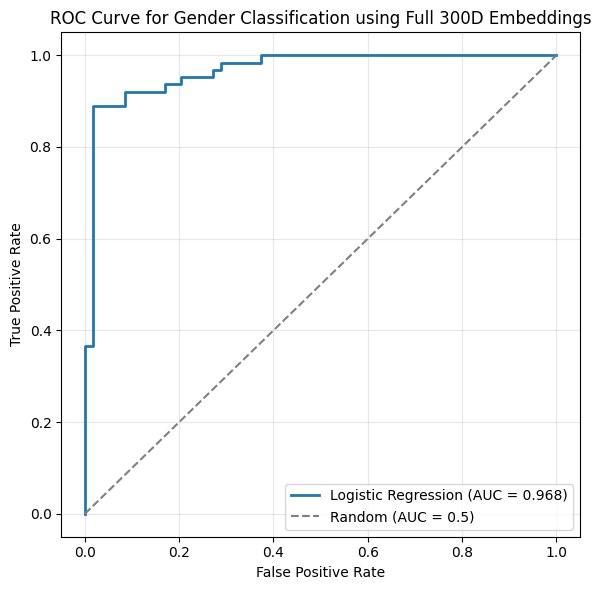

In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_full = np.vstack([male_word_embeddings, female_word_embeddings])
y = np.array([1] * len(male_words) + [0] * len(female_words))

X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.3, random_state=42, stratify=y)

clf_full = LogisticRegression(max_iter=1000)
clf_full.fit(X_train, y_train)
y_score_full = clf_full.decision_function(X_test)
auc_full = roc_auc_score(y_test, y_score_full)
print("AUC with full 300D embeddings:", auc_full)

fpr_full, tpr_full, thresholds_full = roc_curve(y_test, y_score_full)
plt.figure(figsize=(6, 6))
plt.plot(fpr_full, tpr_full, label=f"Logistic Regression (AUC = {auc_full:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random (AUC = 0.5)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Gender Classification using Full 300D Embeddings")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# TODO: dont forget the direction argument of the embeddings and their sign as some additional explanations
# TODO: use sentiments as a limitation since it is not a linear direction that can be captured

## Identify Sentiment Subspace

In [33]:
pos_words = [line.strip() for line in open('../data/positive-words.txt')]
pos_words = [word for word in pos_words if word in model]

neg_words = [line.strip() for line in open('../data/negative-words.txt')]
neg_words = [word for word in neg_words if word in model]

In [34]:
pos_embeddings = np.array([model[w] for w in pos_words])
neg_embeddings = np.array([model[w] for w in neg_words])
all_sentiment_embeddings = np.vstack([pos_embeddings, neg_embeddings])

In [35]:
sent_pca = PCA(n_components=10, random_state=42)
sent_pca.fit(all_sentiment_embeddings)
X_sent = sent_pca.transform(all_sentiment_embeddings)

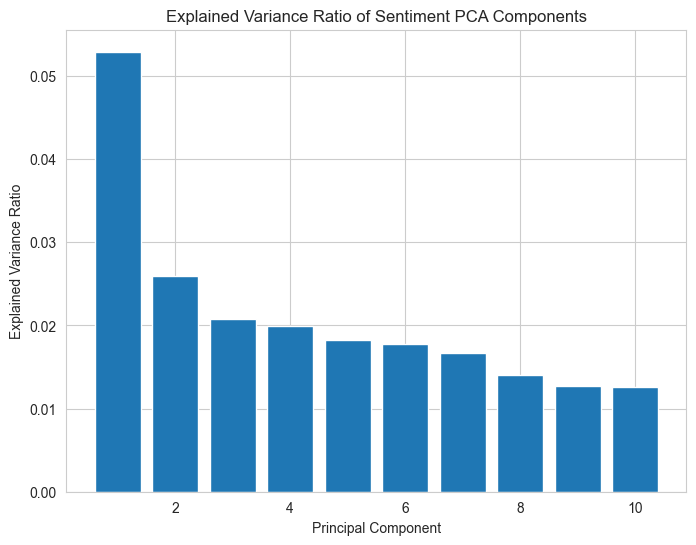

In [36]:
plt.figure(figsize=(8,6))
plt.bar(range(1, len(sent_pca.explained_variance_ratio_) +1), sent_pca.explained_variance_ratio_)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio of Sentiment PCA Components")
plt.show()

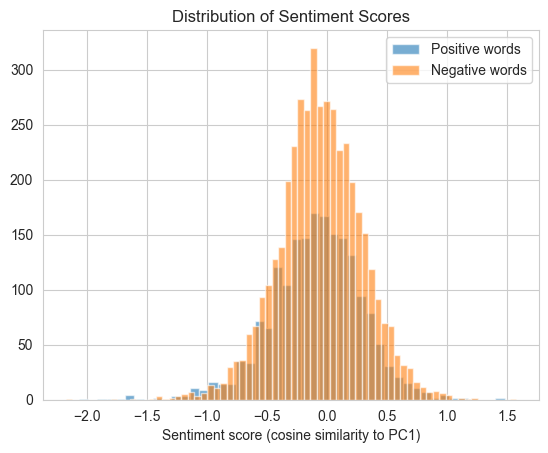

In [39]:
sent_axis = gender_pca.components_[0]
sent_axis = sent_axis / np.linalg.norm(sent_axis)

def sent_score(word):
    return np.dot(model[word], sent_axis)

pos_scores = [sent_score(w) for w in pos_words]
neg_scores = [sent_score(w) for w in neg_words]

plt.hist(pos_scores, bins='auto', alpha=0.6, label='Positive words')
plt.hist(neg_scores, bins='auto', alpha=0.6, label='Negative words')
plt.legend()
plt.xlabel("Sentiment score (cosine similarity to PC1)")
plt.title("Distribution of Sentiment Scores")
plt.show()